# ENTREGA FINAL - VISUALIZACIÓN OBJETIVO GLOBAL OG
### Objetivo Global (OG) de la visualización: Estimar y caracterizar el impacto del ruido ambiental 
Se cuantificará la exposición, población afectada y efectos esperables en la salud, bienestar y productividad, contrastando los resultados con indicadores de desarrollo y bienestar. 
Se considerará el análisis a escala local (Madrid), y nacional (España).

Para el análisis del Objetivo Global (OG) se han seleccionado las siguientes fuentes de datos que permiten medir la exposición a ruido en distintos niveles, comparar indicadores globales de bienestar, desarrollo y prosperidad, analizar tendencias históricas y estándares regulatorios.
* df01: Madrid – Contaminación acústica (SIVCA) - datos diarios (LAeq, L10/L50/L90/L99). 
* df02: Madrid – Contaminación acústica, históricos mensuales (1998–). 
* df03: Define los límites normativos aplicables en España en franjas horarias y entornos. Permite contextualizar si los registros superan los límites legales. 

Las visualizaciones de OG conectan la exposición al ruido con la población afectada y efectos esperables, apoyándose en normativa.
Se realizan 4 visualizaciones:
* OG‑01 Cuantifica exposición real
* OG‑02 Aporta contexto histórico
* OG‑03 Traduce ruido → riesgo sanitario
* OG‑04Integra bienestar y prosperidad

* PREPRARACIÓN DE ENTORNO

In [31]:
import altair as alt

# Se desactiva vegafusion 
alt.data_transformers.enable("default", max_rows=None)

# Renderer compatible con JupyterLab / Anaconda
alt.renderers.enable("mimetype")

RendererRegistry.enable('mimetype')

In [32]:
import pandas as pd
import altair as alt
import requests
import reverse_geocoder as rg
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.decomposition import PCA
from scipy.cluster import hierarchy
from scipy.cluster.hierarchy import fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import unicodedata



pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

* CARGA DE DATOS PREPROCESADOS

In [61]:
# Carga los datos PREPROCESADOS disponibles en Kaggle. En la cuenta del alumno raquelahdo/ruido-datasets-procesados
# https://www.kaggle.com/datasets/raquelahdo/ruido-datasets-procesados

file_path_01_ruido_diario = "df_01_Ruido_diario_acumulado_processed.csv"
file_path_01_daily = "df_01_daily_processed.csv"
file_path_01_daily_plot = "df_01_daily_plot.csv"
file_path_02_cont_acustica = "df_02_contaminacion_acustica_processed.csv"
file_path_02_estac = "df_02_estacion_processed.csv"
file_path_03_noise_lim = "df_03_noise_limit_processed.csv"
# file_path_05_est_ac_proc = "df_05_estaciones-acusticas_processed.csv"
# file_path_06_locales = "df_06_locales_terrazas_processed.csv"
# file_path_07_Mad_Q_vida = "df_07_Madrid-calidad-vida_processed.csv"
file_path_07_Q_vida = "df_07_calidad-vida_processed.csv"
# file_path_07_evo_Q_vida = "df_07_evolucion-calidad-vida_processed.csv"
# file_path_07_evo_long_Q_vida = "df_07_evolucion-long-calidad-vida_processed.csv"
# file_path_07_fin_Q_vida_proc = "df_07_final-calidad-vida_processed.csv"
file_path_09_renta = "df_09_reduced_distribucion-renta_processed.csv"
file_path_os01_actividad_cp = "df_actividad_cp.csv"
file_path_os01_actividad_barrio = "df_actividad_barrio.csv"


df_01_ruido_diario = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_ruido_diario,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_01_daily_plot = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_01_daily_plot,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_cont_acustic = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_cont_acustica,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_02_estac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_02_estac,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_03_noise_lim = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_03_noise_lim,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
#df_05_est_ac = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_05_est_ac_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_06_locales = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_06_locales,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_Mad_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Mad_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_07_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_evo_long_Q_vida = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_evo_long_Q_vida,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
# df_07_fin_Q_vida_proc = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_07_fin_Q_vida_proc,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_09_renta = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_09_renta,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_os01_actividad_cp = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_os01_actividad_cp,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )
df_os01_actividad_barrio = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS, "raquelahdo/ruido-datasets-procesados", file_path_os01_actividad_barrio,pandas_kwargs={"encoding": "utf-8-sig", "sep": ","} )


In [34]:
df_01_ruido_diario.head()

,NMT,year,month,day,periodo,laeq,l1,l10,l50,l90,l99,fecha,periodo_desc,mes_nombre,year_month,week,month_name
0,3,2014,1,1,D,57.4,66.6,61.1,54.3,49.1,45.0,2014-01-01,Diurno,Enero,2014-01,1,Enero
1,30,2014,1,1,D,55.6,64.7,59.2,51.9,45.9,43.5,2014-01-01,Diurno,Enero,2014-01,1,Enero
2,29,2014,1,1,T,57.2,67.4,62.1,49.0,36.6,29.8,2014-01-01,Total,Enero,2014-01,1,Enero
3,29,2014,1,1,N,55.0,66.7,57.4,41.5,30.9,29.2,2014-01-01,Nocturno,Enero,2014-01,1,Enero
4,29,2014,1,1,E,57.4,67.4,62.5,50.2,41.7,36.7,2014-01-01,Vespertino,Enero,2014-01,1,Enero


In [35]:
df_01_daily.head()

,fecha,periodo,laeq
0,2014-01-01,D,60.644
1,2014-01-01,E,61.176
2,2014-01-01,N,68.928
3,2014-01-01,T,66.156
4,2014-01-02,D,63.608


In [36]:
df_01_daily_plot.head()

,fecha,NMT,laeq
0,2014-01-01,3,61.050
1,2014-01-01,4,70.700
2,2014-01-01,5,64.475
3,2014-01-01,8,68.075
4,2014-01-01,10,64.450


In [37]:
df_02_cont_acustic.head()

,estacion,nombre,year,month,ld,le,ln,laeq,l1,l10,l50,l90,l99,fecha,mes_nombre,year_month,month_name
0,RF-19,Alto de Extremadura,1998,9,NaN,NaN,NaN,63.0,72.4,66.3,59.3,51.4,47.0,1998-09-01,Septiembre,1998-09,Septiembre
1,RF-16,Arturo Soria,1998,9,NaN,NaN,NaN,59.5,67.8,61.6,56.0,45.3,39.1,1998-09-01,Septiembre,1998-09,Septiembre
2,RF-14,Plaza Elíptica,1998,9,NaN,NaN,NaN,67.3,75.3,69.8,64.3,56.7,50.0,1998-09-01,Septiembre,1998-09,Septiembre
3,RF-11,Ramón y Cajal,1998,10,NaN,NaN,NaN,70.3,77.2,72.9,68.8,56.8,46.3,1998-10-01,Octubre,1998-10,Octubre
4,RF-14,Plaza Elíptica,1998,10,NaN,NaN,NaN,68.0,75.8,70.2,64.6,56.8,49.8,1998-10-01,Octubre,1998-10,Octubre


In [38]:
df_02_estac.head()

,estacion,laeq
0,RF-01,67.753311
1,RF-02,68.547328
2,RF-03,62.579321
3,RF-04,65.502980
4,RF-05,61.708411


In [39]:
df_03_noise_lim.head()

,noiselimitreportid_identifier,noisesource,limitvaluedefined,status,areatype,noiselevelindicator,limitvalue,explanation,limitvaluedefined_bool,noiselevel
0,LR_ES_00_01,allsources,yes,inforce,hospital,lday,60.0,This is not a limit value but rather an Acoust...,True,day
1,LR_ES_00_01,allsources,yes,inforce,hospital,levening,60.0,This is not a limit value but rather an Acoust...,True,evening
2,LR_ES_00_01,allsources,yes,inforce,hospital,lnight,50.0,This is not a limit value but rather an Acoust...,True,night
3,LR_ES_00_01,allsources,yes,inforce,school,lday,60.0,This is not a limit value but rather an Acoust...,True,day
4,LR_ES_00_01,allsources,yes,inforce,school,levening,60.0,This is not a limit value but rather an Acoust...,True,evening


In [ ]:
# df_05_est_ac.head()

In [ ]:
# df_06_locales.head()

In [ ]:
# df_07_Mad_Q_vida.head()

In [59]:
df_07_Q_vida.head()

,CCAA,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Total Nacional,100.000000,99.171134,98.761457,99.304088,98.663408,98.225947,97.666577,98.261476,98.552239,99.666386,100.448144,101.048758,100.067925,99.822144,100.187631,99.763378,99.983688
1,Andalucía,98.243355,97.380868,96.050234,95.873410,96.286384,95.622403,93.873830,95.430977,95.109237,97.657589,96.327075,97.800458,97.531583,96.583852,97.405337,96.848018,97.669293
2,Aragón,104.665521,105.104032,104.671560,103.980765,103.854998,101.243728,102.009913,103.563863,103.507154,104.988320,105.015362,105.160684,104.967605,103.561554,104.365009,103.033659,102.971541
3,"Asturias, Principado de",104.694153,104.117801,104.823618,104.799107,104.114874,102.477116,102.114463,101.598634,103.343305,102.808435,103.194704,101.713544,101.577220,102.199418,102.777763,102.421108,103.144408
4,"Balears, Illes",98.671469,97.180334,97.344712,96.118689,96.990238,95.750127,95.020305,95.348632,99.342930,97.257662,100.872675,101.463459,100.802315,98.925490,99.182382,99.454337,100.680923


In [ ]:
# df_07_evo_Q_vida.head()

In [ ]:
# df_07_evo_long_Q_vida.head()

In [ ]:
# df_07_fin_Q_vida_proc.head()

In [62]:
df_09_renta.head()

,secciones,periodo,municipio_codigo,municipio_nombre,renta_media
0,"2800401001 Álamo, El sección 01001",2018,28004,"Álamo, El",11.75
1,"2800401001 Álamo, El sección 01001",2019,28004,"Álamo, El",14.00
2,"2800401001 Álamo, El sección 01001",2020,28004,"Álamo, El",11.40
3,"2800401001 Álamo, El sección 01001",2021,28004,"Álamo, El",22.80
4,"2800401001 Álamo, El sección 01001",2022,28004,"Álamo, El",20.90


In [40]:
df_os01_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,2.391304,5467,111
1,28002.0,1.340000,4873,159
2,28003.0,2.857143,4053,190
3,28004.0,1.512821,6274,151
4,28005.0,1.806122,5675,310


In [41]:
df_os01_actividad_barrio.head()

,barrio,hora_cierre_media,num_locales,num_terrazas
0,ABRANTES,15.870089,112,5
1,ACACIAS,16.429717,318,27
2,ADELFAS,18.316111,90,4
3,AEROPUERTO,9.560606,121,0
4,ALAMEDA DE OSUNA,15.987083,80,4


In [42]:
df_os01_actividad_cp.head()

,cod_postal_local,hora_cierre_media,num_locales,num_terrazas
0,28001.0,2.391304,5467,111
1,28002.0,1.340000,4873,159
2,28003.0,2.857143,4053,190
3,28004.0,1.512821,6274,151
4,28005.0,1.806122,5675,310


In [43]:
df_os01_actividad_barrio.head()

,barrio,hora_cierre_media,num_locales,num_terrazas
0,ABRANTES,15.870089,112,5
1,ACACIAS,16.429717,318,27
2,ADELFAS,18.316111,90,4
3,AEROPUERTO,9.560606,121,0
4,ALAMEDA DE OSUNA,15.987083,80,4


 VISUALIZACIÓN OG‑01 · Exposición acústica diaria y distribución poblacional (Madrid)
 * OBJETIVO: distribución real de la exposición diaria al ruido en Madrid.
* Tipo de gráfico: Histograma + densidad (LAeq diario)

* Introduce el problema de forma directa:
Muestra que la exposición no es puntual, sino estructural
Permite estimar población potencialmente afectada

* Datos: df_01_daily (LAeq diario). Obtenido en el proceso de limpieza y noprmalización de df_01

In [44]:
# Usamos SOLO LAeq diario (mucho más ligero)
vals = df_01_daily["laeq"].dropna().values

# Histograma con 40 bins
counts, bin_edges = np.histogram(vals, bins=40)

df_hist_og_01 = pd.DataFrame({
    "bin_start": bin_edges[:-1],
    "bin_end": bin_edges[1:],
    "conteo": counts
})

df_hist_og_01.head()

,bin_start,bin_end,conteo
0,43.464286,44.105095,1
1,44.105095,44.745905,0
2,44.745905,45.386714,0
3,45.386714,46.027524,0
4,46.027524,46.668333,1


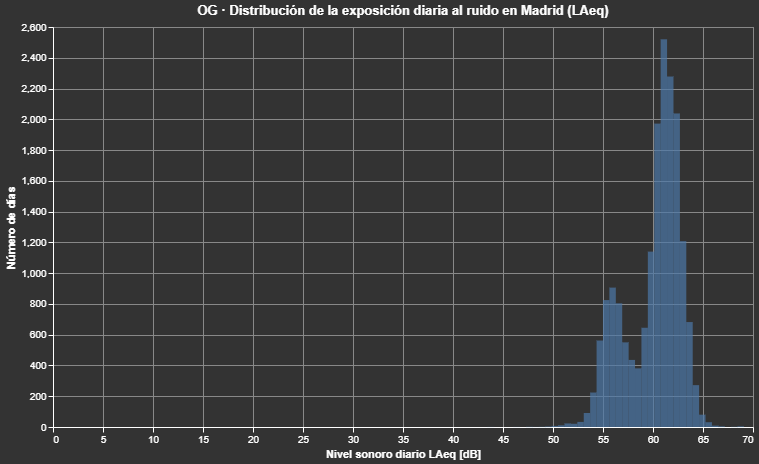

In [46]:
hist_og_01 = (
    alt.Chart(df_hist_og_01)
    .mark_rect(opacity=0.7)
    .encode(
        x=alt.X(
            "bin_start:Q",
            title="Nivel sonoro diario LAeq [dB]"
        ),
        x2=alt.X2("bin_end:Q"),
        y=alt.Y(
            "conteo:Q",
            title="Número de días"
        ),
        tooltip=[
            alt.Tooltip("conteo:Q", title="Días")
        ]
    )
    .properties(
        width=700,
        height=400,
        title="OG · Distribución de la exposición diaria al ruido en Madrid (LAeq)"
    )
)

hist_og_01

 OG‑02 · Evolución histórica del ruido (1998–actualidad)
* OBJETIVO: El ruido urbano mejora, empeora o se mantiene en el largo plazo.
* TIPO DE GRÁFICO: Línea temporal (LAeq / Ln)
* Justificación: Da perspectiva histórica. Permite identificar cambios estructurales. Fundamenta políticas públicas
*
*  Datos: df_02 (históricos mensuales)

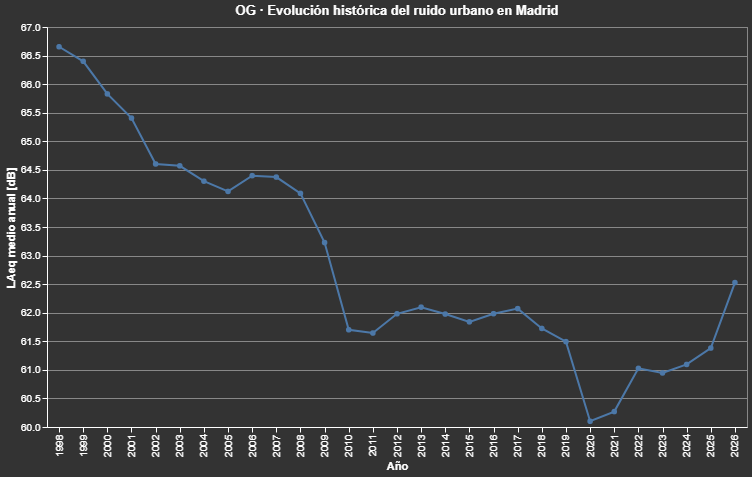

In [47]:
df_ruido_hist = (
    df_02_cont_acustic
    .dropna(subset=["laeq"])
    .groupby("year", as_index=False)
    .agg(laeq_medio=("laeq", "mean"))
)

line_og_02 = (
    alt.Chart(df_ruido_hist)
    .mark_line(point=True)
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y(
            "laeq_medio:Q",
            title="LAeq medio anual [dB]",
            scale=alt.Scale(zero=False)
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("laeq_medio:Q", format=".2f")
        ]
    )
    .properties(
        width=700,
        height=400,
        title="OG · Evolución histórica del ruido urbano en Madrid"
    )
)

line_og_02

OG‑03 · Ruido vs límites normativos (impacto en salud)
🎯 Qué responde
¿Con qué frecuencia se superan los límites legales asociados a efectos sobre la salud?
📊 Tipo
Heatmap + referencia normativa
🧠 Justificación

Traduce decibelios → riesgo
Conecta directamente con salud pública
Muy alineado con ODS y normativa UE

📁 Datos

df_02 (Ln)
df_03 (límites legales)

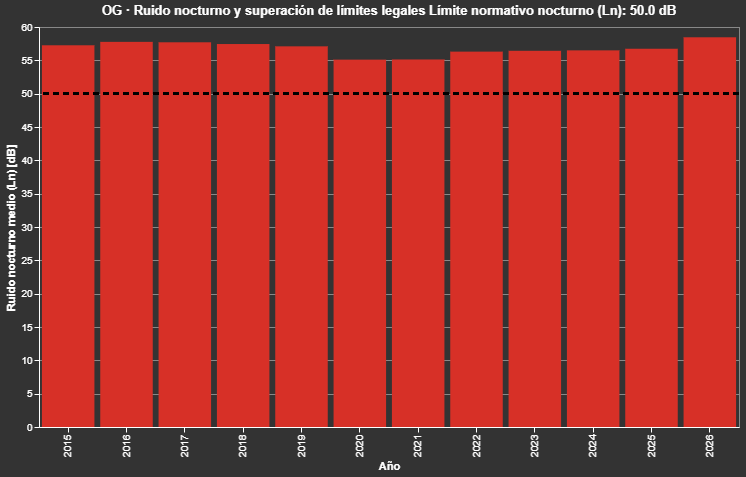

In [54]:
limite_ln = (
    df_03_noise_lim
    .query("noiselevelindicator == 'lnight'")
    ["limitvalue"]
    .iloc[0]
)

df_ln_year = (
    df_02_cont_acustic
    .dropna(subset=["ln"])
    .groupby("year", as_index=False)
    .agg(ln_medio=("ln", "mean"))
)

bars_og_03 = (
    alt.Chart(df_ln_year)
    .mark_bar()
    .encode(
        x=alt.X("year:O", title="Año"),
        y=alt.Y(
            "ln_medio:Q",
            title="Ruido nocturno medio (Ln) [dB]",
            scale=alt.Scale(zero=False)
        ),
        color=alt.condition(
            f"datum.ln_medio > {limite_ln}",
            alt.value("#d73027"),   # rojo: supera límite
            alt.value("#4575b4")    # azul: cumple normativa
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("ln_medio:Q", title="Ln medio", format=".2f")
        ]
    )
)

linea_limite_ln = (
    alt.Chart(df_ln_year)
    .mark_rule(
        strokeDash=[6, 4],
        strokeWidth=2,
        color="black"
    )
    .encode(
        y=alt.datum(limite_ln)
    )
)


og_03_final = (
    (bars_og_03 + linea_limite_ln)
    .properties(
        width=700,
        height=400,
        title=(
            "OG · Ruido nocturno y superación de límites legales\n"
            f"Límite normativo nocturno (Ln): {limite_ln} dB"
        )
    )
)

og_03_final

El límite normativo nocturno se representa mediante una línea de referencia superpuesta, lo que permite identificar visualmente los periodos en los que los niveles medios de ruido superan los umbrales asociados a efectos adversos sobre la salud.

OG‑04 · Síntesis global: ruido, bienestar y prosperidad (España)
🎯 Qué responde
¿Cómo se relaciona el ruido con indicadores agregados de bienestar y desarrollo?
📊 Tipo
Scatter + tamaño (visión integrada)
🧠 Justificación

Conecta OG con OS02 y OS03
Da visión macro
Ideal como cierre del proyecto

📁 Datos

Ruido agregado (df_02)
Indicadores agregados (OS02 / OS03)
* calculamos df_og_integrado  es un dataset sintético, creado solo para el Objetivo Global, que integra por año:
Ruido medio anual
Indicador agregado de bienestar
Indicador agregado de prosperidad

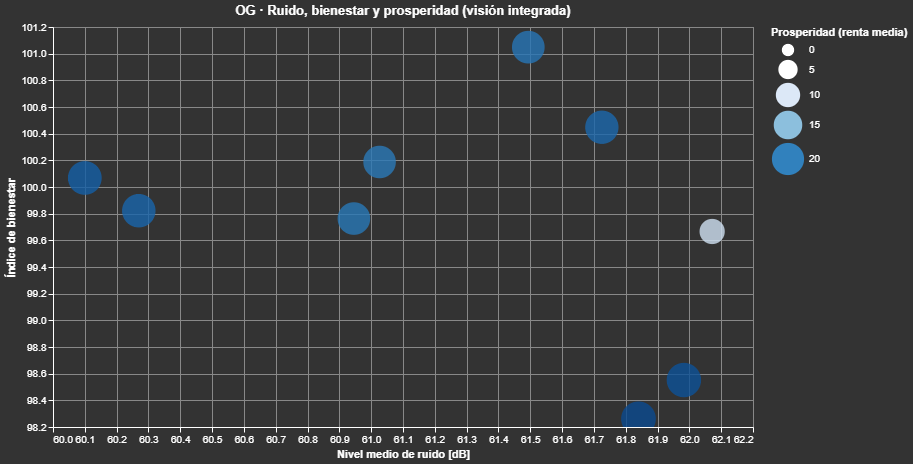

In [64]:
# =========================================================
# 1. RUIDO MEDIO ANUAL (Madrid / conjunto disponible)
# =========================================================
df_ruido_og = (
    df_02_cont_acustic
    .dropna(subset=["laeq"])
    .groupby("year", as_index=False)
    .agg(
        ruido_medio=("laeq", "mean")
    )
)

# =========================================================
# 2. BIENESTAR AGREGADO (Total Nacional)
# =========================================================
df_bienestar_og = (
    df_07_Q_vida
    .query("CCAA == 'Total Nacional'")
    .drop(columns=["CCAA"])
    .melt(var_name="year", value_name="indice_bienestar")
)

df_bienestar_og["year"] = df_bienestar_og["year"].astype(int)

# =========================================================
# 3. PROSPERIDAD (RENTA MEDIA AGREGADA)
# =========================================================
df_prosperidad_og = (
    df_09_renta
    .rename(columns={"periodo": "year"})
    .groupby("year", as_index=False)
    .agg(
        indicador_prosperidad=("renta_media", "mean")
    )
)

# =========================================================
# 4. DATASET INTEGRADO OG
# =========================================================
df_og_integrado = (
    df_ruido_og
    .merge(df_bienestar_og, on="year", how="inner")
    .merge(df_prosperidad_og, on="year", how="inner")
)

# =========================================================
# 5. VISUALIZACIÓN OG‑04 (SCATTER INTERACTIVO)
# =========================================================
scatter_og_04 = (
    alt.Chart(df_og_integrado)
    .mark_circle(opacity=0.8)
    .encode(
        x=alt.X(
            "ruido_medio:Q",
            title="Nivel medio de ruido [dB]",
            scale=alt.Scale(zero=False)
        ),
        y=alt.Y(
            "indice_bienestar:Q",
            title="Índice de bienestar",
            scale=alt.Scale(zero=False)
        ),
        size=alt.Size(
            "indicador_prosperidad:Q",
            title="Prosperidad (renta media)",
            scale=alt.Scale(range=[150, 1200])
        ),
        color=alt.Color(
            "indicador_prosperidad:Q",
            title="Prosperidad (renta media)",
            scale=alt.Scale(scheme="blues"),
            legend=alt.Legend(orient="right")
        ),
        tooltip=[
            alt.Tooltip("year:O", title="Año"),
            alt.Tooltip("ruido_medio:Q", title="Ruido medio", format=".1f"),
            alt.Tooltip("indice_bienestar:Q", title="Bienestar", format=".2f"),
            alt.Tooltip("indicador_prosperidad:Q", title="Prosperidad", format=".1f")
        ]
    )
    .interactive()
    .properties(
        width=700,
        height=400,
        title="OG · Ruido, bienestar y prosperidad (visión integrada)"
    )
)

scatter_og_04